# 나만의 챗봇만들기

## 실습 1 - 주가 분석(Single-turn)

### 혼자해보기

In [81]:
# env 설정

from dotenv import load_dotenv
import os

load_dotenv(override=True)

api_key = os.getenv("OPENAI_API_KEY")
g_api_key = os.getenv("GEMINI_API_KEY")

default_model = os.getenv("OPENAI_DEFAULT_MODEL")
g_default_model = os.getenv("GEMINI_DEFAULT_MODEL")

upstage_api_key = os.getenv("UPSTAGE_API_KEY")

gocamping_api_key = os.getenv("GOCAMPING_API_KEY")

from openai import OpenAI

client = OpenAI()
print(g_default_model)

gemini-2.5-flash


- 최근 30일 동안의 삼성전자 주가 데이터를 가져와서 분석하는 ChatGPT 어플리케이션을 작성하시오.   (힌트: pykrx 패키지)
- 입력 프롬프트 : 삼성전자, 30일

In [ ]:
# tools에서 pykrs사용
# 함수 정의

from pykrx import stock
import pandas as pd


def using_pykrx(corp: str, start_date: str, end_date: str):
    """
    KRX에서 특정 기업의 일별 OHLCV 데이터를 가져와 문자열로 반환
    """

    # 1. 전체 시장에서 종목명으로 티커 찾기
    target_ticker = None

    for market in ["KOSPI", "KOSDAQ", "KONEX"]:
        tickers = stock.get_market_ticker_list(market=market)

        for ticker in tickers:
            name = stock.get_market_ticker_name(ticker)

            if name == corp:
                target_ticker = ticker
                print(f"종목명: {name}, 종목코드: {target_ticker}, 시장: {market}")
                break

        if target_ticker:
            break

    # 2. 종목을 못 찾은 경우
    if target_ticker is None:
        return f"'{corp}'에 해당하는 종목코드를 찾지 못했습니다. 기업명을 정확히 입력해주세요."

    # 3. 주가 데이터 조회
    try:
        df = stock.get_market_ohlcv_by_date(
            fromdate=start_date,
            todate=end_date,
            ticker=target_ticker
        )
    except Exception as e:
        return f"pykrx 데이터 조회 중 오류가 발생했습니다: {e}"

    # 4. 데이터가 비어 있는 경우
    if df is None or df.empty:
        return (
            f"{corp}({target_ticker})의 {start_date}부터 {end_date}까지 "
            "조회된 주가 데이터가 없습니다. 날짜가 거래일 범위인지 확인해주세요."
        )

    print(df.head())

    return df.to_string()

In [20]:
tools = [
    {
        "type": "function",
        "name": "using_pykrx",
        "description": "한국거래소(KRX)에서 특정 기업의 지정된 기간 동안의 일별 주가 데이터(시가, 고가, 저가, 종가, 거래량)를 가져오는 함수",
        "parameters": {
            "type": "object",
            "properties": {
                "corp": {
                    "type": "string",
                    "description": "정확한 기업 이름. 예: 삼성전자, SK하이닉스"
                },
                "start_date": {
                    "type": "string",
                    "description": "조회 시작일. YYYYMMDD 형식. 예: 20260516"
                },
                "end_date": {
                    "type": "string",
                    "description": "조회 종료일. YYYYMMDD 형식. 예: 20260616"
                }
            },
            "required": ["corp", "start_date", "end_date"],
            "additionalProperties": False
        },
        "strict": True
    }
]

tool_map = {
    "using_pykrx": using_pykrx
}

In [ ]:
corp = '삼성전자'
start_date = '20260516'
end_date = '20260616'
input_msg = [{'role':'user','content':f'{corp}의 {start_date}부터 {end_date} 까지의 주가데이터를 상세히 분석해줘'}]

ret1 = client.responses.create(
    model = default_model, # type: ignore
    input = input_msg, # type: ignore
    tools = tools, # type: ignore
    tool_choice = "auto"
)
print(ret1) ;print(ret1.output)

Response(id='resp_0b6724803fef93b4006a31edd452208199a3a1633e9748ff90', created_at=1781657044.0, error=None, incomplete_details=None, instructions=None, metadata={}, model='gpt-4o-mini-2024-07-18', object='response', output=[ResponseFunctionToolCall(arguments='{"corp":"삼성전자","start_date":"20260516","end_date":"20260616"}', call_id='call_XBR15EsNHdNY4kOXU4bNWf2i', name='using_pykrx', type='function_call', id='fc_0b6724803fef93b4006a31edd51fd081999cb402d8bed65283', namespace=None, status='completed')], parallel_tool_calls=True, temperature=1.0, tool_choice='auto', tools=[FunctionTool(name='using_pykrx', parameters={'type': 'object', 'properties': {'corp': {'type': 'string', 'description': '정확한 기업 이름. 예: 삼성전자, SK하이닉스'}, 'start_date': {'type': 'string', 'description': '조회 시작일. YYYYMMDD 형식. 예: 20260516'}, 'end_date': {'type': 'string', 'description': '조회 종료일. YYYYMMDD 형식. 예: 20260616'}}, 'required': ['corp', 'start_date', 'end_date'], 'additionalProperties': False}, strict=True, type='functi

In [ ]:
import json

#================================ 1차 호출
# tool의 결과와 gpt ret1의 결과를 같이 봐야하니까 리스트로 저장
tool_output = []

for item in ret1.output:
    if item.type == 'function_call':
        func_name = item.name 
        arguments = json.loads(item.arguments or '{}')

        result = tool_map[func_name](**arguments) # type: ignore
        tool_output.append({
            'type':'function_call_output',
            'call_id' : item.call_id,
            'output': result
        })

# 결과 확인
print(result)

#================================ 2차 호출
# 함수 실행 결과를 모델에 다시 전달
if tool_output:                     # tool이 호출된 경우
    ret2 = client.responses.create( # 2차 요청: 함수 실행 결과를 모델에 다시 전달
        model = default_model, # type: ignore
        input = input_msg + ret1.output + tool_output # type: ignore
        # 원래 입력 + 1차 모델 출력 + 함수 실행 결과를 함께 전달
        # 이렇게 해야 모델이 최종 자연어 답변을 생성할 수 있음 
    ) 
    print(ret2.output_text)    # 최종 자연어 응답 출력
else:
    print(ret1.output_text)    # tool call 없이 바로 답변이 나온 케이스


### 강사님과 해보기

In [31]:
from pykrx import stock
from datetime import datetime, timedelta
import pandas as pd

def get_stock_price(ticker,day):
    end_date = datetime.now()
    start_date = end_date - timedelta(days=30)

    df = stock.get_market_ohlcv_by_date(start_date.strftime(('%Y%m%d')),
                                        end_date.strftime(('%Y%m%d')),
                                        ticker)
    return df




ticker = '005930'
df = get_stock_price(ticker,30)
df.head(3)

KRX 로그인 시도...
  로그인 ID: my_fake_id
KRX 로그인 실패: 자격 증명을 확인하세요.


,시가,고가,저가,종가,거래량,등락률
날짜,,,,,,
2026-05-18,269500,288500,262000,281000,33555214,3.881701
2026-05-19,274000,281500,266000,275500,30767569,-1.957295
2026-05-20,278000,282500,263500,276000,35662077,0.181488


In [28]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
시가,21.0,3.122381e+05,2.538386e+04,2.695000e+05,2.930000e+05,3.100000e+05,3.320000e+05,3.605000e+05
고가,21.0,3.220476e+05,2.607101e+04,2.815000e+05,3.020000e+05,3.190000e+05,3.430000e+05,3.700000e+05
저가,21.0,3.045119e+05,2.537647e+04,2.620000e+05,2.875000e+05,3.000000e+05,3.250000e+05,3.480000e+05
종가,21.0,3.138810e+05,2.526455e+04,2.755000e+05,2.990000e+05,3.070000e+05,3.330000e+05,3.605000e+05
거래량,21.0,3.048109e+07,9.359801e+06,4.910909e+06,2.705036e+07,3.142031e+07,3.566208e+07,4.505249e+07
등락률,21.0,1.136491e+00,5.466778e+00,-1.018237e+01,-2.442997e+00,1.780415e+00,4.496124e+00,1.009464e+01


In [ ]:
latest_price =df['종가'].iloc[-1]
highest_price =df['고가'].max()
lowest_price =df['저가'].min()
average_price =df['종가'].mean()


analysis = (
    f"최근 30일 동안 삼성전자의 종가 데이터를 분석한 결과는 다음과 같습니다\n"
    f"Latest Price: {latest_price}\n"
    f"Highest Price in the period: {highest_price}\n"
    f"Lowest Price in the period: {lowest_price}\n"
    f"Average Price in the period: {average_price}"
    f"이 데이터를 기반으로 간단한 분석과 전망을 제공해주세요"
)


ret = client.responses.create(
    model=default_model, # type: ignore
    instructions='당신은 대한민국 주식분석 전문가입니다. 다음데이터를 기반으로 상세한 분석과 전망을 제공하세요.',
    input=analysis
)

print(ret.output[0].content[0].text) # type: ignore

삼성전자의 최근 30일 종가 데이터를 바탕으로 한 분석은 다음과 같습니다.

### 1. 가격 변동성 분석
- **최고가**: 370,000원
- **최저가**: 262,000원
- **가격 변동폭**: 370,000 - 262,000 = 108,000원
- **변동성**: 가격이 약 40% 이상 움직였으며, 이는 상당한 변동성을 나타냅니다. 이는 투자자들이 불안정한 시장 환경에 있는 경우 자주 발생할 수 있습니다.

### 2. 평균 가격
- **평균 가격**: 약 313,881원
- 현재 종가(333,000원)는 평균 가격보다 높습니다. 이는 현재 주가가 평균보다 강세를 보이고 있음을 나타내며, 긍정적인 모멘텀을 보이고 있습니다.

### 3. 현재 가격 분석
- 현재 가격(333,000원)은 최근 최고가(370,000원)와 비교했을 때 10% 가까이 낮은 수준입니다. 하지만 최저가(262,000원)와 비교하면 상당히 높은 수준입니다. 이는 현재 가격이 여전히 비교적 안정적인 모멘텀을 갖고 있음을 보여줍니다.

### 4. 기술적 분석
- 가격이 평균 가격을 넘어서면서 지지는 확고해 보이며, 앞으로 상승세를 이어갈 가능성이 있을 것으로 판단됩니다. 하지만 최근 최고가와 최저가 간의 큰 차이를 고려할 때, 단기적으로 어떠한 조정이 있을 수도 있습니다.

### 5. 전망
- **중기적인 전망**: 삼성전자는 글로벌 반도체 시장, 스마트폰 판매량, 그리고 5G 및 AI 관련 사업에서의 성장 잠재력을 갖고 있어 긍정적인 전망이 기대됩니다. 만약 강력한 실적 발표 및 긍정적인 시장 환경이 동반된다면, 가격은 이전 최고가에 다시 도달할 가능성이 큽니다.
- **단기적인 전망**: 단기적으로는 가격이 어느 정도 조정을 받을 수 있으며, 특히 시장 전반의 심리에 따라 영향을 미칠 수 있습니다. 긴 박스권 이동을 보일 수도 있으니, 이러한 점을 고려하여 매매 전략을 세우는 것이 좋습니다.

### 결론
삼성전자는 현재 긍정적인 모멘텀을 보이고 있으며, 다만 단기적인 변동

## 실습 2 - 캠핑장 추천 (Single-turn)

- 입력 프롬프트 <br>
prompt = 계곡이 있는 캠핑장을 추천해줘. <br>
prompt = 가족과 함께 주말을 보낼 수 있는 캠핑장 추천해줘.

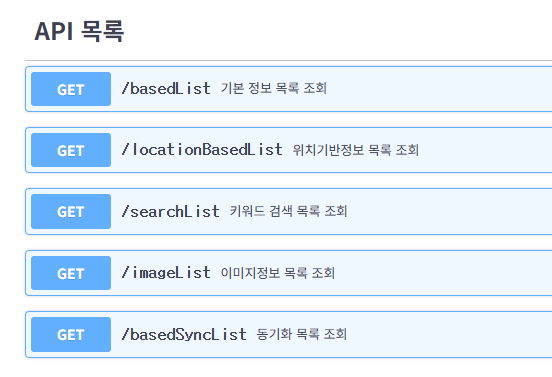

In [ ]:
# 오류남 - 키가 유효하지않다고

""" keyword = "캠핑"

url = f'http://apis.data.go.kr/B551011/GoCamping/searchList?serviceKey=(gocamping_api_key)&MobileOS=ETC&MobileApp=AppTest&keyword={keyword}&_type=json'

print(url) """

http://apis.data.go.kr/B551011/GoCamping/searchList?serviceKey=(gocamping_api_key)&MobileOS=ETC&MobileApp=AppTest&keyword=캠핑&_type=json


In [ ]:
import urllib.parse

# 2. 핵심: API 키 내부에 있을지 모를 특수문자(+, /, = 등)를 주소창 전용 문자로 인코딩합니다.
encoded_key = urllib.parse.quote(gocamping_api_key) # type: ignore

keyword = "캠핑"

# 3. 인코딩된 키를 사용해 f-string으로 URL을 생성합니다.
url = f'http://apis.data.go.kr/B551011/GoCamping/searchList?serviceKey={encoded_key}&MobileOS=ETC&MobileApp=AppTest&keyword={keyword}&_type=json'

print("수동으로 완성된 URL 주소:")
print(url)

수동으로 완성된 URL 주소:
http://apis.data.go.kr/B551011/GoCamping/searchList?serviceKey=13c820d62992689526a049075035e63bf7d7e4addc547bf4ab9caad24ce2a426&MobileOS=ETC&MobileApp=AppTest&keyword=캠핑&_type=json


### 생성된 url로 키워드 분석 해보기

- 입력 프롬프트 <br>

처음에 키워드 추출 <br>

prompt = 계곡이 있는 캠핑장을 추천해줘. <br>
prompt = 가족과 함께 주말을 보낼 수 있는 캠핑장 추천해줘.

In [ ]:
import requests
import json

while True:
    input_message = input("질문을 입력하세요(종료하려면 'quit'입력) : ").strip()
    if input_message.lower() == "quit": 
        print("프로그램을 종료합니다.")
        break

    # ================= 호출1 : 질문자의 키워드를 추출 =================
    ret1 = client.responses.create(
        model = default_model, # type: ignore
        instructions = (
            "당신은 키워드 추출 전문가입니다. 다음 질문에서 핵심 키워드들을 골라내어 "
            "설명 없이 오직 공백(스페이스바)으로만 구분해서 나열하세요.\n"
            "단, '오토캠핑'처럼 개별 키워드 내부에는 절대 띄어쓰기를 포함하지 마세요.\n"
            "예시: 차박 글글램핑 바다 오토캠핑"
        ),
        input = input_message
    )

    # 추출된 키워드 문자열 (예: "차박 바다 불멍")
    combined_keywords = ret1.output[0].content[0].text.strip() # type: ignore
    print("AI가 추출한 복합 키워드:", combined_keywords)

    # URL 생성 및 인코딩
    encoded_key = urllib.parse.quote(gocamping_api_key) # type: ignore
    encoded_keywords = urllib.parse.quote(combined_keywords)
    
    url = f'http://apis.data.go.kr/B551011/GoCamping/searchList?serviceKey={encoded_key}&MobileOS=ETC&MobileApp=AppTest&keyword={encoded_keywords}&_type=json'

    print("\n수동으로 완성된 URL 주소:")
    print(url)

    # 직접 URL에 접속해서 JSON 데이터를 긁어오기.
    try:
        response = requests.get(url)
        
        if response.status_code == 200:
            # 긁어온 JSON 데이터를 파이썬 딕셔너리/리스트 형태로 변환
            fetched_data = response.json()
            
            # LLM이 읽기 편하도록 깔끔하게 정돈된 문자열(JSON String)로 변환
            camping_data_str = json.dumps(fetched_data, ensure_ascii=False, indent=2)
            print("공공데이터포털에서 성공적으로 JSON 데이터를 읽어왔습니다.")
        else:
            camping_data_str = f"데이터 로드 실패 (HTTP 에러 코드: {response.status_code})"
            print("데이터 로드 실패")
            
    except Exception as e:
        camping_data_str = f"데이터를 긁어오는 중 시스템 오류 발생: {str(e)}"
        print("스크래핑 오류 발생")

    # ================= 호출2 : AI가 키워드 중심으로 답변 =================
    analysis = (
        f"사용자가 원하는 주요 키워드 그룹: {combined_keywords}\n\n"
        f"[고캠핑 실시간 조회 데이터 원본]\n"
        f"{camping_data_str}\n\n"
        f"위의 실시간 JSON 데이터를 바탕으로, 사용자가 언급한 키워드들과 가장 매칭이 잘 되는 캠핑 명소들을 선별하여 상세히 분석하고 코스를 추천해 주세요."
    )

    ret2 = client.responses.create(
        model=default_model, # type: ignore
        instructions="너는 캠핑관광 전문가야. 제공된 실제 JSON 데이터 본문을 참고하여 사용자의 키워드 성격에 딱 맞는 맞춤형 캠핑 코스를 구체적으로 추천해줘.",
        input=analysis
    )

    print("\n[캠핑 전문가 AI의 답변]")
    print(ret2.output[0].content[0].text) # type: ignore
    print('='*100)

AI가 추출한 복합 키워드: 차박 연인 캠핑장 추천

수동으로 완성된 URL 주소:
http://apis.data.go.kr/B551011/GoCamping/searchList?serviceKey=13c820d62992689526a049075035e63bf7d7e4addc547bf4ab9caad24ce2a426&MobileOS=ETC&MobileApp=AppTest&keyword=%EC%B0%A8%EB%B0%95%20%EC%97%B0%EC%9D%B8%20%EC%BA%A0%ED%95%91%EC%9E%A5%20%EC%B6%94%EC%B2%9C&_type=json
공공데이터포털에서 성공적으로 JSON 데이터를 읽어왔습니다.

[캠핑 전문가 AI의 답변]
사용자가 원하는 "차박 연인 캠핑장"에 맞춘 맞춤형 캠핑 코스를 아래와 같이 추천드립니다. 이 코스는 연인과의 특별한 시간을 즐길 수 있는 장소들을 포함하고 있습니다.

### 1. 감성 캠핑장: **소양강 스카이워크**
- **위치**: 강원도 춘천시
- **차박 특성**: 넓은 주차공간과 자연속에서의 차박이 가능.
- **추천 이유**: 아름다운 소양강의 경치와 스카이워크에서의 멋진 뷰가 연인과 함께하는 로맨틱한 분위기를 연출합니다.
- **부대시설**: 바베큐 시설, 공용 화장실, 샤워실

### 2. 힐링 캠핑장: **양평 청운캠프**
- **위치**: 경기도 양평군
- **차박 특성**: 조용한 자연 속에서의 차박 공간 제공.
- **추천 이유**: 조용하고 아늑한 분위기의 캠핑장으로, 연인과 함께 한가롭게 자연을 만끽할 수 있습니다.
- **부대시설**: 토끼 및 양 떼와의 교감, 자전거 대여 서비스

### 3. 바다 캠핑장: **홍도캠핑장**
- **위치**: 전라남도 완도군
- **차박 특성**: 바다와 가까운 전용 주차 공간.
- **추천 이유**: 아름다운 해변과 일몰을 감상할 수 있는 기회, 연인과의 해변 산책이 가능합니다.
- **부대시설**: 해수욕장 근처, 바비큐장, 화장실

### 4. 

### 강사님과 함께

In [ ]:
question1 = '계곡이 있는 캠핑장을 추천해줘'
question2 = '가족과 함께 즐길 수 있는 캠핑장을 추천해줘'

ret1 = client.responses.create(
    model=default_model, # type: ignore
    instructions='다음 질문에서 사용자가 원하는 결과를 검색하기에 가장 중요할 단어 하나만 찾아줘',
    input=question2
)

print(ret1.output[0].content[0].text)  # type: ignore
keyword = ret1.output[0].content[0].text # type: ignore

캠핑장


In [ ]:
url = f'http://apis.data.go.kr/B551011/GoCamping/searchList?serviceKey={gocamping_api_key}&MobileOS=ETC&MobileApp=AppTest&keyword={keyword}&_type=json'
print(url)

http://apis.data.go.kr/B551011/GoCamping/searchList?serviceKey=13c820d62992689526a049075035e63bf7d7e4addc547bf4ab9caad24ce2a426&MobileOS=ETC&MobileApp=AppTest&keyword=캠핑&_type=json


In [ ]:
import requests # http통신 라이브러리
import json

res = requests.get(url)
print(res) # 200나오면 제대로 갖고온 것(정상 수신) / 400 : 접속이 안됨 / 500 : 서버에 문제있음

<Response [200]>


In [62]:
res.json()

{'response': {'header': {'resultCode': '0000', 'resultMsg': 'OK'},
  'body': {'items': {'item': [{'contentId': '3587',
      'facltNm': '횡성군 병지방 오토캠핑장',
      'lineIntro': '병지방 계곡에 위치한 대형 공공 캠핑장',
      'intro': '병지방 계곡의 상류에 위치한 병지방 오토캠핑장은 계곡을 따라 길게 조성되어 있다. 산뒷골 37면, 양지말 56면, 당거리 26명등 종합 119면의 캠핑 사이트를 보유한 대형 캠핑장으로 횡성군에서 조성, 위틱운영하고 있다.  샤워장,화장실. 쉼터, 음수대. 물놀이 공원, 체육시성들 다양한 편의시설을 골고루 갖추고 있을 뿐 아니라. 캠핑장내 산책로와 공터에 동물조형물과 캐릭터 벤치를 설해 놓았다. 어린이를 동반한 가족 캠퍼들을 위한 배려다. 이외에도 소나무가 있는 공간에 거울 기둥을 설치해 토포존 역할을 하도록 했으며, 정자옆에는 연못 트릭아트를 그려 시각적 재미를 주고 있다.    캠핑장이 있는 병지방 계곡은 6km에 걸쳐 맑은 물이 흐르고, 바로 옆으로 어답산 등산로가 있어 다양한 아웃도어 여행을 즐길 수 있다.',
      'allar': '0',
      'insrncAt': 'Y',
      'trsagntNo': '2015000016',
      'bizrno': '',
      'facltDivNm': '민간',
      'mangeDivNm': '직영',
      'mgcDiv': '',
      'manageSttus': '운영',
      'hvofBgnde': '',
      'hvofEnddle': '',
      'featureNm': '',
      'induty': '일반야영장',
      'lctCl': '',
      'doNm': '강원특별자치도',
      'sigunguNm': '횡성군',
      'zipcode': '225

In [69]:
data = res.json()
site = data['response']['body']['items']['item']

context = ''
for site in site:
    context += f"{site['facltNm']} : {site['lineIntro']} : {site['addr1']}\n"

print(context)

횡성군 병지방 오토캠핑장 : 병지방 계곡에 위치한 대형 공공 캠핑장 : 강원특별자치도 횡성군 갑천면 어답산로 516 
캠핑플래닛 : 아치산 중턱에서 바라보는 전망 좋은 캠핑장 : 경기도 포천시 화현면 봉화로 400-150
천왕산 가족캠핑장 : 농촌체험 등 가족형 즐길거리가 있는 도심 캠핑장 : 서울특별시 구로구 연동로12길 149 (항동)
양주 리온 캠핑장 :  : 경기도 양주시 마전로212번길 79-72 (마전동)
꼬꼬토피아 캠핑 : 넓고 쾌적한 자연경관, 전용 카페와 닭 공예품 전시관 : 강원특별자치도 영월군 주천면 황산벌길 186
강릉 바다내음 캠핑장 :  : 강원특별자치도 강릉시 강동면 율곡로 1616
상무평화공원 캠핑장 :  : 전라남도 장성군 삼계면 영장로 1738-16
다포캠핑장 : 거제 남부면 다포마을에 위치한 프라이빗한 오토캠핑장 : 경상남도 거제시 남부면 다포리 199-10
신선오토캠핑장 : 넓은 사이트와 깔끔한 편의시설을 갖춘 영월의 자연 친화적 오토캠핑장 : 강원특별자치도 영월군 무릉도원면 중방안길 34-10
캠핑옴 :  : 충청북도 단양군 가곡면 남한강로 1077



In [ ]:
ret2 = client.responses.create(
    model=default_model, # type: ignore
    instructions=f"주어진 문장들을 보고, 다음 질문에 대답해줘 : {question2}",
    input=context
)

print(ret2.output[0].content[0].text) # type: ignore

가족과 함께 즐길 수 있는 캠핑장을 추천드리자면:

1. **천왕산 가족캠핑장** - 서울특별시 구로구에 위치하며, 농촌체험 등 다양한 가족형 즐길거리가 있어 아이들과 함께 방문하기 좋은 장소입니다.

2. **횡성군 병지방 오토캠핑장** - 강원도 횡성군에 위치하고, 대형 공공 캠핑장으로 자연경관이 아름답고 가족 단위 방문객에게 적합합니다.

3. **꼬꼬토피아 캠핑** - 강원도 영월군에 위치, 넓고 쾌적한 자연 속에서 전용 카페와 닭 공예품 전시관이 있어 가족과 함께 다양한 체험을 즐길 수 있습니다.

이 외에도 필요에 따라 다른 캠핑장들을 고려해볼 수 있습니다. 각 캠핑장에 따라 다양한 편의 시설과 자연 환경을 제공하니, 가족 구성원의 취향에 맞게 고르시면 좋겠네요!


# Langchain 

- 단순한 텍스트 생성 작업에는 OpenAI API만으로도 충분할 수 있으나, 다단계 처리, 맥락 유지, 외부 도구 연동이 필요한 경우에는 LangChain이 보다 구조적인 해결책을 제공한다.
- OpenAI API와 같은 LLM 호출 방식은 단일 요청-응답 구조에 적합하다.
- 그러나 실제 AI 응용 시스템에서는 다음과 같은 요구가 발생한다.
    - 이전 대화를 기억해야 함
    - PDF를 읽어야 함
    - 데이터베이스를 검색해야 함
    - 웹 검색을 해야 함
    - 여러 단계를 순서대로 실행해야 함
    - 외부 API와 연결해야 함

이러한 복잡한 작업을 체계적으로 구성하기 위해 LangChain을 사용한다.

- LangChain은 LLM 주변의 다양한 기능을 연결해 주는 역할을 한다.

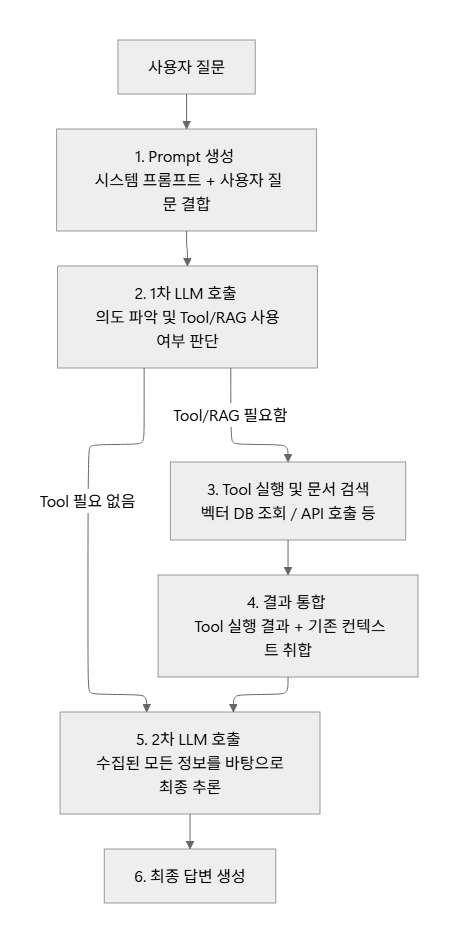

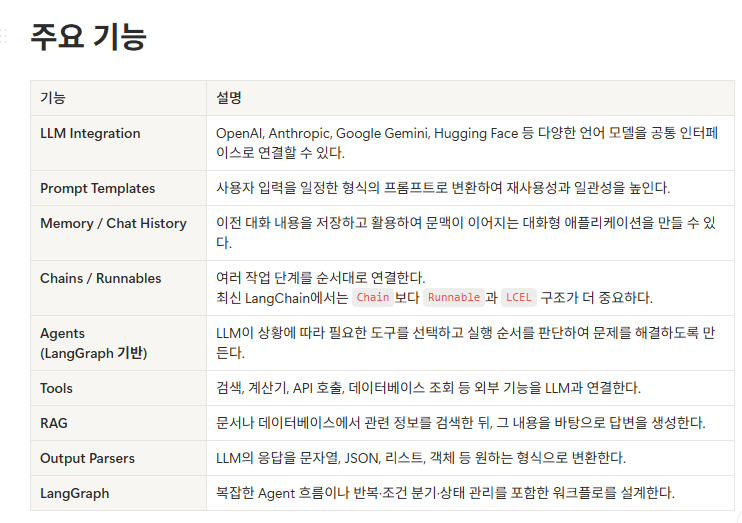

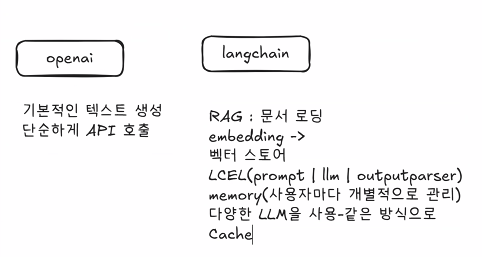

# LangChain 예제

- 리스트 형태로 메세지 보냄 → LangChain의 메세지 기반 대화 방식 사용
- System Message로 AI의 전문성 설정 → Human Message로 구체적인 질문 전달
- OpenAI의 모델(GPT-4o) / Gemini 모델 (gemini-2.5-flash) 활용

## OpenAI API 사용

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model=default_model)  # type: ignore

In [ ]:
### OpenAI 모델로 해보기

from langchain_core.messages import HumanMessage, SystemMessage

messages = [
    SystemMessage(content = '당신은 서울의 음식과 문화에 대한 전문가 입니다.특히나 젊은 세대의유행흐름을 잘 아는 전문가입니다.'),
    HumanMessage(content = '서울에서 맛집 3곳만 추천해줘')
]

response = llm.invoke(messages)
print(response.content)

서울에서 맛집으로 추천할 만한 3곳을 소개해드릴게요!

1. **이태원 "부대찌개"**:
   부대찌개는 이태원에서 특히 유명한 음식으로, 한국 전통 음식과 서양 스타일이 혼합된 요리입니다. 이곳의 부대찌개는 다양한 재료와 깊은 국물 맛으로 젊은 세대에게 큰 인기를 끌고 있습니다. 재료를 추가해 나만의 레시피로 즐길 수 있어 다양하게 즐길 수 있습니다.

2. **홍대 "마라탕"**:
   요즘 마라탕은 많은 사람들에게 사랑받고 있는 음식입니다. 홍대 인근에는 다양한 마라탕 가게가 있는데, 매운 맛과 풍부한 재료 조합이 특징입니다. 특히, 나만의 다양한 재료를 선택할 수 있어 개인의 취향에 맞게 즐길 수 있어 더 인기가 많습니다.

3. **강남 "치킨 & 맥주"**:
   한국의 프라이드 치킨과 맥주는 절묘한 궁합을 자랑합니다. 강남 지역에는 특별한 양념과 소스를 사용하는 치킨 맛집이 많습니다. 특히, 다양한 종류의 크래프트 맥주와 함께 즐길 수 있는 곳이 많아 젊은 세대에게 인기가 많습니다.

이 외에도 서울에는 다양한 맛집이 많으니, 꼭 방문해보시길 권장합니다!


In [ ]:
### Geminai 모델로 해보기

from langchain_google_genai import ChatGoogleGenerativeAI

g_llm = ChatGoogleGenerativeAI(model=g_default_model)

response = g_llm.invoke(messages)
print(response.content)

서울에는 다양한 맛집이 있지만, 특히 젊은 세대에게 인기 있는 세 곳을 추천해드리겠습니다.

1. **홍대의 '미래의 맛' (Future Flavor)**  
   이곳은 퓨전 요리와 현대적인 분위기를 강조한 식당으로, 다양한 느낌의 일식과 양식이 잘 결합된 메뉴를 제공합니다. 특히 비건 메뉴가 다양하게 준비되어 있어 건강과 맛을 모두 챙길 수 있습니다.

2. **부산어묵 골목 (Busan Eomuk Alley)**  
   이곳은 부산어묵을 전문으로 하는 가게들이 모여 있는 골목입니다. 다양한 맛의 어묵을 한 번에 즐길 수 있고, 젊은 세대들 사이에서 인스타그램 스팟으로 유명합니다. 따뜻한 어묵 국물과 함께 다양한 안주를 즐길 수 있어 소셜 미디어에서도 큰 인기를 끌고 있습니다.

3. **이태원의 '밥보이' (Bapboy)**  
   이태원에 위치한 이곳은 퓨전 한식을 주제로 한 레스토랑으로, 특히 다양한 비빔밥 메뉴가 인기입니다. 해산물, 고기, 채소 등을 조합해 창의적인 비빔밥을 제공하며, 젊은 고객들이 많이 찾아오는 핫플레이스입니다.

이 외에도 서울에는 많은 맛집이 있으니, 다양한 경험을 즐겨보시길 바랍니다!


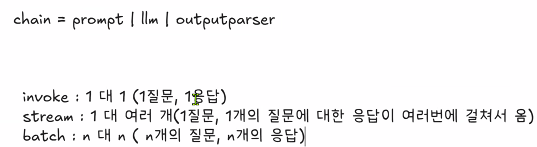

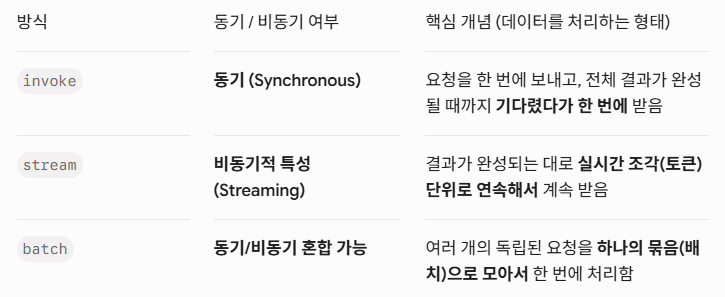

- 동기식(sync) : 한 프로세스 씩 실행(에스컬레이터 한 줄짜리 한개) ( 1인이 *10개 작업 ) -> 대신 정밀도 높음
- 비동기식(async) : 한꺼번에 여러명이 넓은 에스컬레이터 타는 것 ( 10인이 * 1개 작업 ) -> 대신 정밀도 떨어짐

In [89]:
messages1 = [
    SystemMessage(content = '당신은 서울의 음식과 문화에 대한 전문가 입니다.특히나 젊은 세대의유행흐름을 잘 아는 전문가입니다.'),
    HumanMessage(content = '서울에서 맛집 3곳만 추천해줘')
]

messages2 = [
    SystemMessage(content = '당신은 부산의 음식과 문화에 대한 전문가 입니다.특히나 젊은 세대의유행흐름을 잘 아는 전문가입니다.'),
    HumanMessage(content = '부산에서 맛집 3곳만 추천해줘')
]

messages3 = [
    SystemMessage(content = '당신은 제주도의 음식과 문화에 대한 전문가 입니다.특히나 젊은 세대의유행흐름을 잘 아는 전문가입니다.'),
    HumanMessage(content = '제주도에서 맛집 3곳만 추천해줘')
]

## invoke

In [ ]:
import time

start = time.time()

response1 = llm.invoke(messages1)
print('ret1 : ', response1.content)  
med1 = time.time()
print(f'ret1 소요시간 : {med1 - start:.2f}초') 
print('='*50)

response2 = llm.invoke(messages2)
print('ret2 : ', response2.content)  
med2 = time.time()
print(f'ret2 소요시간 : {med2 - med1:.2f}초')
print('='*50)

response3 = llm.invoke(messages3)
print('ret3 : ', response3.content) 
med3 = time.time()
print(f'ret3 소요시간 : {med3 - med2:.2f}초')  
print('='*50)

print(f'총 소요시간 : {med3 - start:.2f}초')

ret1 :  서울의 젊은 세대 유행 흐름을 잘 아는 전문가로서, 요즘 가장 핫하고 '힙'한 감성을 만족시킬 만한 맛집 3곳을 엄선해서 추천해 드릴게요! 맛은 물론이고 분위기, 콘셉트까지 고려했습니다.

---

### **1. 몽탄 (Mongtan) - 삼각지점**

*   **추천 이유:** 요즘 가장 '핫'한 고깃집 중 하나예요. 일반적인 삼겹살집과는 다르게 짚불에 초벌한 소갈비(우대갈비)가 시그니처 메뉴인데, 비주얼부터 압도적이고 풍미가 정말 독특하고 맛있어요. 레트로하면서도 힙한 인테리어와 분위기 덕분에 젊은 세대에게 특히 인기가 많죠. 웨이팅이 길어도 '이건 기다릴 만하다!'는 생각이 들 거예요.
*   **메뉴:** 짚불 우대갈비, 몽탄 삼겹살, 비빔냉면, 볶음밥 등
*   **분위기:** 복고풍의 독특한 인테리어, 활기차고 힙한 분위기.
*   **팁:** 웨이팅이 어마어마하니, 오픈런을 하거나 테이블링 같은 앱으로 미리 예약하는 걸 추천해요. 고기 구워주는 서비스도 완벽해서 편하게 즐길 수 있습니다.

---

### **2. 온량 (Onryang) - 성수점**

*   **추천 이유:** 성수동은 지금 서울에서 가장 트렌디한 동네 중 하나인데, 그 중심에 있는 '온량'은 감각적인 인테리어와 함께 맛있는 양식 메뉴를 선보여요. 특히 크림 파스타와 스테이크 메뉴가 인기가 많고, 플레이팅도 예뻐서 사진 찍기에도 좋아요. 데이트 코스로도, 친구들과의 모임에도 완벽한 곳이죠.
*   **메뉴:** 트러플 크림 파스타, 라구 파스타, 항정살 스테이크, 리조또 등
*   **분위기:** 모던하고 감성적인 인테리어, 아늑하면서도 세련된 분위기.
*   **팁:** 성수동의 핫한 카페나 편집샵들과 함께 동선을 짜서 방문하기 좋아요. 식사 후 근처 카페에서 커피 한 잔 하는 코스를 추천합니다.

---

### **3. 살라댕방콕 (Saladaeng Bangkok) - 익선동점**

*   **추천 이유:** 익선동은 고즈넉한 한옥 골목에 젊은 감각의 맛집과

In [98]:
import time

start = time.time()

response1 = await llm.ainvoke(messages1)
response2 = await llm.ainvoke(messages2)
response3 = await llm.ainvoke(messages3)

end = time.time()

print(f'소요시간 : {end-start:.2f}초')

소요시간 : 19.70초


## Stream

In [97]:
messages1 = [
    SystemMessage(content = '당신은 서울의 음식과 문화에 대한 전문가 입니다.특히나 젊은 세대의유행흐름을 잘 아는 전문가입니다.'),
    HumanMessage(content = '서울에서 맛집 3곳만 추천해줘')
]

response = llm.stream(messages1)
for chunk in response:
    print(chunk.content, end="", flush=True)

서울에는 다양한 맛집들이 많지만, 젊은 세대에게 인기 있는 세 곳을 추천드릴게요!

1. **마포갈매기** (마포구)
   - 이곳은 갈매기살을 전문으로 하는 고기집으로, 신선한 고기를 불판에서 직접 구워먹을 수 있어요. 고기 외에도 다양한 반찬과 소스가 함께 제공되어 더욱 맛있게 즐길 수 있습니다. 특히 소주와 함께하면 최고!

2. **이태원 브런치 카페 '피크닉'** (이태원)
   - 이태원에 위치한 이 카페는 아늑한 분위기와 트렌디한 메뉴가 인상적이에요. 다양한 브런치 메뉴와 음료가 풍성하게 준비되어 있으며, 특히 아보카도 토스트와 팬케이크가 인기입니다. 친구들과 여유로운 주말 브런치를 즐기기 좋아요.

3. **홍대 '오장동 떡볶이'** (마포구)
   - 이곳은 매운 떡볶이로 유명한 곳으로, 젊은 세대들 사이에서 핫플레이스입니다. 다양한 튀김과 오징어, 덮밥 등과 함께 떡볶이를 즐길 수 있으며, 소스를 선택할 수 있어 취향에 맞게 즐길 수 있습니다. 특히 야외 좌석이 있어 친구들과 함께 즐기기에도 좋습니다.

이 세 곳은 각각의 매력이 있어 젊은 세대에게 인기가 많습니다. 서울 여행하실 때 꼭 한번 들러보세요!

In [ ]:
# astream이면 async로 받은때까지 기다렸다가 스트림으로 내보내기

response = llm.astream(messages1)
async for chunk in response:
    print(chunk.content, end="", flush=True)

서울에는 정말 많은 맛집이 있지만, 특히 요즘 젊은 세대 사이에서 인기를 끌고 있는 3곳을 추천해드릴게요.

1. **마녀주방 (Mysterious Kitchen)**
   - 위치: 홍대
   - 추천 메뉴: 라비올리, 리소토
   - 설명: 이탈리안 퓨전 요리를 즐길 수 있는 곳으로, 아기자기한 인테리어와 독특한 요리로 인기를 끌고 있습니다. 특히 수제 면 요리가 유명하며, 친구들과 함께 하기에 좋은 장소입니다.

2. **이화 소반**
   - 위치: 이대
   - 추천 메뉴: 한정식, 비빔밥
   - 설명: 전통 한식을 현대적으로 재해석한 장소로, 다양한 한정식 메뉴를 제공합니다. 건강한 재료들로 가득한 이곳은 맛뿐만 아니라 비주얼도 뛰어나 인스타그램에 올리기 좋은 장소입니다.

3. **백리향 (Bai Lih Yang)**
   - 위치: 강남
   - 추천 메뉴: 딤섬, 볶음밥
   - 설명: 현대적인 중화 요리 레스토랑으로, 신선한 재료와 다양한 딤섬으로 유명합니다. 고급스러운 분위기에서 소중한 사람들과 함께 특별한 식사를 즐기기에 적합한 곳입니다.

이 restaurantes는 모두 젊은 세대 사이에서 핫플레이스로 자리 잡고 있으니, 꼭 한번 방문해보세요!

## Batch

In [ ]:
messages4 = [
    [SystemMessage(content='당신은 서울의 음식과 문화에 대한 전문가입니다.'),
    HumanMessage(content='서울에서 맛있는 음식점 2곳만 추천해줘')],
    [SystemMessage(content='당신은 부산의 음식과 문화에 대한 전문가입니다.'),
    HumanMessage(content='부산에서 맛있는 음식점 2곳만 추천해줘')],
    [SystemMessage(content='당신은 제주도의 음식과 문화에 대한 전문가입니다.'),
    HumanMessage(content='제주도에서 맛있는 음식점 2곳만 추천해줘')]
]

# await에 걸려있으면, 내 작업은 내가 기다렸다가 출력

responses = llm.batch(messages4)
for response in responses : 
    print(response.content)

서울에서 맛있는 음식점을 두 곳 추천해드릴게요!

1. **미슐랭 가이드에 선정된 '진진'**: 이곳은 정통 중식당으로, 평양냉면과 다양한 중국 요리를 제공합니다. 특히, 탕수육과 함 바리에 올린 고기 요리가 유명합니다. 런치 메뉴도 괜찮아서 부담 없이 방문할 수 있습니다.

2. **'조선옥'**: 서울에서 전통 한식을 경험하고 싶다면 조선옥을 추천합니다. 이곳은 갈비찜과 해물파전으로 유명합니다. 신선한 재료를 사용하여 건강한 한식을 즐길 수 있는 곳입니다.

이 두 곳은 특별한 날에 가족이나 친구와 함께 가기 좋은 맛집입니다. 예약을 권장해드립니다!
부산에서 추천할 만한 맛있는 음식점 두 곳을 소개해드릴게요.

1. **광안리 해물탕**: 광안리 해변 근처에 위치한 이곳은 신선한 해산물을 사용한 해물탕이 유명합니다. 바다의 신선한 맛이 가득한 해물탕을 뜨끈하게 즐길 수 있으며, 해변을 바라보며 식사를 할 수 있어 경치도 좋습니다.

2. **서면 돼지국밥**: 부산의 대표적인 음식 중 하나인 돼지국밥을 즐길 수 있는 곳으로, 서면에 위치해 있습니다. 진한 육수와 부드러운 돼지고기가 어우러져 깊은 맛을 자랑하며, 고소한 밥과 함께 먹으면 더욱 맛있습니다. 부산의 정취를 느낄 수 있는 따뜻한 식당입니다.

이 두 곳에서 부산의 맛을 제대로 느껴보세요!
제주도에서 맛있는 음식점 두 곳을 추천해드릴게요!

1. **흑돈가**: 제주도의 대표적인 음식인 흑돼지고기를 전문으로 하는 맛집입니다. 신선한 제주 흑돼지고기를 사용하여 구워내며, 고기의 육즙과 풍미가 뛰어나고, 다양한 반찬과 함께 즐길 수 있습니다. 현지인들에게도 인기가 많은 곳입니다.

2. **동문시장에서의 해물뚝배기**: 제주도 동문시장 안에는 신선한 해산물을 사용한 해물 뚝배기를 판매하는 여러 가게가 있습니다. 특히, 다양한 해산물과 함께 끓여낸 얼큰한 국물이 일품으로, 제주에서 직접 잡은 신선한 해산물을 맛볼 수 있는 기회를 제공합니다. 시장을 돌아다니며 여러 음식을 경험하는 재미도 있습니다.

제주

In [102]:
responses = await llm.abatch(messages4)
for response in responses:
    print(response.content)

서울에서 맛있는 음식점을 두 곳 추천해 드릴게요!

1. **미소야 (Miso-ya)** - 이곳은 전통적인 일본 라멘을 전문으로 하는 곳으로, 깊고 진한 국물과 신선한 면발이 특징입니다. 다양한 종류의 라멘과 사이드 메뉴도 있어서 많은 사람들이 찾는 인기 있는 장소입니다. 특히, 돼지고기 차슈가 부드럽고 풍미가 좋아요.

2. **목멱산 뒷골목 (Mokmyeoksan Back Alley)** - 이곳은 서울의 전통 한식을 경험할 수 있는 곳으로 추천드립니다. 다양한 찌개와 반찬이 함께 제공되는 정식 메뉴가 특히 유명하며, 특히 김치찌개와 불고기가 인기입니다. 아늑한 분위기에서 진정한 한식의 맛을 느낄 수 있습니다.

이 두 곳은 각각의 매력이 있어 꼭 추천드리고 싶습니다!
부산에서 맛있는 음식점을 두 곳 추천해드릴게요.

1. **밀면집 (Makchang)**: 부산의 대표적인 면 요리인 밀면을 전문으로 하는 집입니다. 쫄깃한 면과 시원한 육수가 일품이며, 비빔밀면도 인기 있습니다. 특히 여름철에는 더위를 날려주는 메뉴로 많은 사랑을 받고 있습니다.

2. **동래 파전 (Dongnae Pajeon)**: 부산의 전통적인 해산물 전을 맛볼 수 있는 곳입니다. 감자와 해산물, 그리고 파를 넉넉히 넣은 파전이 바삭하고 부드럽습니다. 이와 함께 막걸리를 곁들여 먹으면 최고의 조화를 이루죠. 

부산의 맛을 즐겨보세요!
제주도에서 맛있는 음식점을 두 곳 추천해드릴게요!

1. **돈사돈**: 제주도의 흑돼지고기를 전문으로 하는 식당으로, 신선한 재료와 함께 맛있는 고기를 즐길 수 있습니다. 고기의 질이 뛰어나고, 다양한 부위의 흑돼지를 맛볼 수 있는 곳으로, 특히 돼지 불고기와 목살이 인기입니다. 불판에서 구운 고기를 소금 또는 특제 소스와 함께 즐겨보세요.

2. **아방가**: 제주에서 유명한 해산물 전문 식당으로, 신선한 회와 해산물 요리를 제공합니다. 특히 제주바다에서 잡아올린 다양한 생선과 해산물을 즐길 수 있으며, 싱싱한 회와 함께 나오는 해물뚝배기가 인

# Prompt Template

## LangChain Prompt template

<aside>
💡

- Prompt란 무엇인가?
- Prompt Template 종류
    - PromptTemplate
        - 기본구조
        - 실습하기
        - 저장된 템플릿(template.json)
        - 저장된 템플릿 가져오기
    - **🔍** from_template
    - **🔍** ChatPromptTemplate
    - FewShotPromptTemplate
</aside>

### 프롬프트(Prompt)란 무엇인가?

- **정의**: LLM(대형언어모델)에게 "무엇을, 어떻게 해달라"고 지시하는 자연어 명령문이다.
- **본질**: 사람에게 질문할 때도 명확하게 요청해야 원하는 답을 얻듯, LLM에게도 프롬프트는 "명령어이자 대화의 시작점"이 된다.

> 💡 **동일한 주제, 완전히 다른 결과 (예시)**
> 
> - **일반 지시**: *"고양이에 대해 설명해줘."*
> - **구체적 지시**: *"고양이를 5살 아이가 즉시 이해할 수 있게 쉬운 비유를 들어 설명해줘."*
> 
> 두 프롬프트는 동일한 정보를 요청하지만, 타겟팅된 지시어 하나로 답변의 깊이와 어조(Tone & Manner)가 완전히 달라진다. 결국 **프롬프트의 설계(=프롬프트 엔지니어링)가 답변의 질을 결정한다**.
>

In [105]:
from langchain_core.prompts import PromptTemplate

template = PromptTemplate(
    input_variable = ['topic'],
    template='오늘은 {topic}에 대해서 알려줘'
)

prompt = template.format(topic='무궁화꽃')
print(prompt)

print(llm.invoke(prompt))

오늘은 무궁화꽃에 대해서 알려줘
content='무궁화(무궁화꽃)는 대한민국의 국가 꽃으로, 학명은 \'Hibiscus syriacus\'입니다. 무궁화는 아욱과에 속하는 낙엽성 관목으로 여름철에 풍성한 꽃을 피우는 특징이 있습니다. 다음은 무궁화꽃에 대한 몇 가지 정보입니다.\n\n### 특징\n1. **꽃과 잎**: 무궁화는 여름에 크고 화려한 꽃을 여러 개 피우며, 색상은 보통 흰색, 분홍색, 보라색 등 다양합니다. 꽃은 일반적으로 5개의 꽃잎으로 구성되어 있습니다.\n2. **잎**: 잎은 깊은 잎자루를 가지며, 가장자리가 톱니 모양입니다. 보통 어긋나며, 여름철에 푸른 색을 띱니다.\n3. **높이**: 무궁화는 보통 1.5m에서 3m까지 자라며, 잘 자라게 관리하면 더 크게 기를 수 있습니다.\n\n### 상징성\n- **대한민국의 국화**: 무궁화는 국화를 상징하는 꽃으로, "무궁"이라는 이름은 "영원히 피어난다"는 의미를 지닙니다. 이는 나라의 번영과 지속성을 상징합니다.\n- **문화적 의미**: 무궁화는 한국의 역사와 문화에서 중요한 위치를 차지하고 있으며, 여러 작품에서 주제로 등장하기도 합니다.\n\n### 생육 환경\n무궁화는 햇볕을 잘 받아야 성장하며, 배수가 잘 되는 토양에서 잘 자랍니다. 비교적 기후 변화에 강하고, 다양한 환경에서도 잘 자라는 편입니다.\n\n### 재배 및 관리\n- **심기**: 일반적으로 봄이나 가을에 심으며, 햇볕이 잘 드는 곳에 두는 것이 좋습니다.\n- **물주기**: 생육기인 여름철에는 정기적으로 물을 주어야 하며, 너무 물 빠짐이 좋은 토양에서 기르는 것이 이상적입니다.\n- **전정(가지치기)**: 겨울철, 나무가 휴면기에 있을 때 가지치기를 해주면 더욱 건강하게 자랄 수 있습니다.\n\n무궁화는 아름다움과 상징성으로 많은 사람들에게 사랑받고 있는 꽃입니다. ' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'compl

### 실습하기

- 프롬프트 예제 2)
    - 프로야구 / 3개 팀
    - 프로축구 / 5개 팀

In [112]:
from langchain_core.prompts import PromptTemplate

template = PromptTemplate(
    input_variable = ['topic','num'],
    template='오늘은 대표적인 {topic}의 {num}개 알려줘'
) # type: ignore

prompt1 = template.format(topic='한국프로 야구팀',num=3)
print(llm.invoke(prompt1).content)
print("="*50)
prompt2 = template.format(topic='한국프로 축구팀',num=5)
print(llm.invoke(prompt2).content)



한국 프로 야구의 대표적인 팀으로는 다음 세 팀이 있습니다:

1. **두산 베어스** - 서울을 연고로 한 팀으로, KBO리그에서 여러 차례 우승한 전통적인 강호입니다.
2. **LG 트윈스** - 역시 서울을 연고로 하는 팀으로, 팬층이 두텁고 많은 역사를 가진 팀입니다.
3. **삼성 라이온즈** - 대구를 연고로 하며, KBO리그에서 가장 많은 우승 기록을 보유한 팀 중 하나입니다.

이 외에도 많은 팀들이 활발히 경쟁하고 있습니다!
한국 프로 축구팀 중 대표적인 팀 5개는 다음과 같습니다:

1. **FC 서울** - K리그1 소속의 전통적인 강팀으로, 많은 팬을 보유하고 있으며 여러 차례 리그 우승 경험이 있습니다.

2. **전북 현대 모터스** - K리그1에서 뛰어난 성적을 기록하고 있는 팀으로, 다수의 리그 우승 및 AFC 챔피언스리그에서도 좋은 성적을 거둔 바 있습니다.

3. **수원 삼성 블루윙즈** - K리그1의 전통적인 라이벌 중 하나로, 많은 팬층과 역사적인 성적을 가진 팀입니다. 

4. **울산 현대** - K리그1의 강자로, 리그 우승과 컵 대회에서 많은 성과를 이뤄낸 팀입니다. 

5. **포항 스틸러스** - K리그1에서 오랜 역사를 가진 팀으로, 여러 차례 리그 및 컵 대회에서 우승한 경험이 있습니다.

이 팀들은 한국 축구의 역사에서 중요한 위치를 차지하고 있습니다.


In [118]:
template = PromptTemplate.from_template("{topic}의 {num}개 알려줘")
prompt = template.format(topic='프로야구',num=3)
print(llm.invoke(prompt).content)

프로야구와 관련된 3가지 주요 요소를 알려드릴게요!

1. **리그 구조**: 프로야구는 일반적으로 두 개 이상의 리그로 나뉘어 운영됩니다. 예를 들어, 한국에서는 KBO 리그가, 미국에서는 메이저 리그 베이스볼(MLB)이 있습니다. 각 리그는 시즌 동안 팀 간의 경기를 진행하며, 최종적으로 각 리그의 챔피언을 결정합니다.

2. **팀과 선수**: 프로야구에는 여러 팀이 참여하며, 각 팀은 유능한 선수를 영입하여 경쟁합니다. 선수들은 타격, 투구, 수비 등 다양한 역할을 맡고 있으며, 일부 선수들은 스타로 발돋움하여 팬층을 형성하기도 합니다.

3. **팬 문화**: 프로야구는 강력한 팬 문화를 가지고 있습니다. 팬들은 경기 관람을 즐기고, 응원 단체를 구성하거나 구단의 유니폼을 입고 경기를 응원합니다. 각 팀의 고유한 응원가와 응원 문화를 통해 팬들은 더욱 열렬하게 팀을 지지합니다.

이 외에도 프로야구에는 여러 흥미로운 요소가 많습니다! 궁금한 점이 있으면 더 물어보세요.


In [119]:
template.save('a.json')

C:\Users\KDA 25\AppData\Local\Temp\ipykernel_6280\2454403698.py:1: LangChainDeprecationWarning: The method `BasePromptTemplate.save` was deprecated in langchain-core 1.2.21 and will be removed in 2.0.0. Use `Use `dumpd`/`dumps` from `langchain_core.load` to serialize prompts and `load`/`loads` to deserialize them.` instead.
  template.save('a.json')


In [120]:
from langchain_core.prompts import load_prompt

template = load_prompt('a.json')
prompt = template.format(topic='프로축구',num=5)
print(llm.invoke(prompt).content)

프로 축구와 관련된 5개 주요 리그를 소개하겠습니다.

1. **프리미어 리그 (Premier League)** - 잉글랜드의 최상위 프로 축구 리그로, 세계적인 인기를 끌고 있으며 많은 스타 선수들이 활약하고 있습니다.

2. **세리에 A (Serie A)** - 이탈리아의 최상위 프로 축구 리그로, 역사와 전통이 깊고, AC 밀란, 유벤투스, 인터밀란 등의 유명 클럽이 있습니다.

3. **라리가 (La Liga)** - 스페인의 최상위 프로 축구 리그로, FC 바르셀로나와 레알 마드리드가 대표적인 팀으로 알려져 있습니다.

4. **분데스리가 (Bundesliga)** - 독일의 최상위 프로 축구 리그로, 바이에른 뮌헨과 보루시아 도르트문트 같은 강팀들이 있는 리그입니다.

5. **Ligue 1** - 프랑스의 최상위 프로 축구 리그로, 파리 생제르맹(PSG)이 최근 몇 년간 우 dominance를 보이고 있습니다.

이 외에도 많은 나라에서 프로 축구 리그가 운영되고 있으며, 각 리그마다 고유의 매력을 가지고 있습니다.


## ChatPromptTemplate
- ChatPromptTemplate.from_messages([])

In [125]:
template = ChatPromptTemplate.from_messages([
    ('system', "너는 친절한 한국어 챗봇이야. 답변은 간단히 5줄로 해줘."),
    ('user', "{input}")
])
prompt = template.format_messages(input='프로야구 3개팀에 대해 알려줘')
result = llm.invoke(prompt)

print(result.content)

물론이죠! 

1. **두산 베어스**: 서울을 연고지로 하는 팀으로, KBO 리그에서 여러 차례 우승한 전통의 강팀입니다.
2. **LG 트윈스**: 역시 서울을 기반으로 하며, 열정적인 팬층과 함께 지난 몇 년 동안 좋은 성적을 거두고 있습니다.
3. **삼성 라이온즈**: 대구를 연고로 하는 팀으로, 다수의 우승 경력을 보유하고 있는 KBO의 대표팀입니다. 

이들 모두 한국 프로야구에서 중요한 팀들이에요!


In [128]:
chain = template | llm
ret = chain.invoke({'input':'프로야구 3개팀에 대해 알려줘'})
print(ret.content)

한국 프로야구의 대표적인 팀 세 가지를 소개할게요.

1. **두산 베어스**: 서울을 연고로 하고 있으며, 다수의 한국 시리즈 우승 기록을 가진 전통의 강팀입니다.
2. **SK 와이번스**: 인천을 연고로 하며, 2000년대 초부터 강력한 전력을 자랑해왔습니다. 최근 팀명이 SSG 랜더스로 변경되었습니다.
3. **롯데 자이언츠**: 부산을 연고로 하고 있고, passionate한 팬층을 보유한 팀입니다. 오랜 역사와 함께 여러 차례 우승 경험이 있습니다. 

각 팀은 고유의 특징과 팬 문화를 가지고 있어요!


In [ ]:
""" 실습해보기========================================================
시스템 메세지 : 훌륭한 가이드, 고객 최적의 여행 일정 수립을 도와줍니다.
user 메세지 : {when} {place} {travel}을 계획하고있습니다.
ai 메세지: 내가 바로 {place}의 여행 전문가입니다.
user 메세지 : {question} # 해당 지역의 여행지 5군데를 추천해주세요 """

In [130]:
template = ChatPromptTemplate.from_messages([
    ('system', "훌륭한 가이드, 고객 최적의 여행 일정 수립을 도와줍니다."),
    ('user', "{when} {place} {travel}을 계획하고있습니다."),
    ('ai','내가 바로 {place}의 여행 전문가입니다.'),
    ('user','{question}')
])
prompt = template.format_messages(
    when = '7월',
    place = '일본 오사카',
    travel = '가족여행',
    question = '맛집 위주로 5박6일 여행계획을 세우고 싶어')
result = llm.invoke(prompt)

print(result.content)

오사카는 맛집이 많은 도시로 유명합니다. 아래는 5박 6일 동안의 오사카 맛집 여행 일정입니다.

### 1일차: 도착 및 난바 지역 탐방
- **오전**: 오사카 도착 후 호텔 체크인
- **점심**: **돈카츠** - '하루카스 차카츠' (소문난 돈까스 전문점)
- **오후**: 난바 지역 탐방 (도톤보리 거리 방문)
- **저녁**: **타코야키** - '어나이스 타코야키' (도톤보리에서 인기 있는 타코야키 가게)

### 2일차: 주요 관광지 및 미식
- **오전**: 오사카 성 방문
- **점심**: **오코노미야키** - '사쿠라야' (오사카 명물 오코노미야키)
- **오후**: 유니버설 스튜디오 일본 방문
- **저녁**: **이자카야** - '야키토리 아츠시' (맛있는 닭꼬치 이자카야)

### 3일차: 고베로의 일일 여행
- **오전**: 고베 방문 (고베 규 육회로 유명)
- **점심**: **고베 소고기** - '고베비프 굽기' (고급스러운 고베 소고기 식당)
- **오후**: 고베 항구 및 메리켄 파크 산책
- **저녁**: 고베 지역의 **스시** - '스시 만잔' (신선한 초밥)

### 4일차: 오사카 주변 탐방
- **오전**: **우메다 스카이 빌딩** 방문
- **점심**: **햄버거** - '모스버거' (일본식 햄버거 맛집)
- **오후**: 텐노지 신사 방문
- **저녁**: **유바리** - '다코야키와 가라아게의 조합'

### 5일차: 쇼핑 및 다양한 미식
- **오전**: 신사이바시 쇼핑 거리 탐방
- **점심**: **라면** - '이치란 라멘' (인기 라멘 체인)
- **오후**: 오사카의 상점가 및 기념품 쇼핑
- **저녁**: **이탈리안** - '트라토리아 도리아' (이탈리안 레스토랑)

### 6일차: 출국 전 마무리
- **오전**: 마지막 쇼핑 및 자유시간
- **점심**: **도시락 또는 편의점 음식** - 일본 편의점에서 다양한 맛을 경험
- **오후**: 공항으로 이동 및 출국

각 식당은 미리 예

In [131]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model=default_model)

In [ ]:
# PromptTemlplate -> 일반적인 Q&A텍스트
from langchain_core.prompts import PromptTemplate
